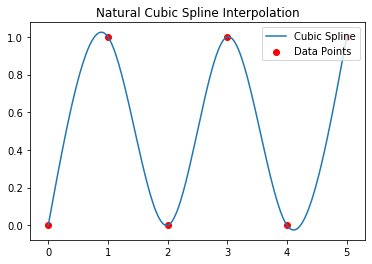

In [31]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0,1,2,3,4,5], dtype=float)
y = np.array([0,1,0,1,0,1], dtype=float)

n = len(x)

h = np.diff(x)

A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

B[0] = 1
B[-1] = 1

for i in range(1, n-1):
    A[i] = h[i-1]
    B[i] = 2 * (h[i-1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    
for i in range(1, n):
    w = A[i] / B[i-1]
    B[i] = B[i] - w * C[i-1]
    D[i] = D[i] - w * D[i-1]
    
M = np.zeros(n)
M[-1] = D[-1] / B[-1]

for i in range(n-2, -1, -1):
    M[i] = (D[i] - C[i] * M[i+1]) / B[i]
    
def eval_spline(xeval):
    for i in range(n-1):
        if x[i] <= xeval <= x[i+1]:
            hi = h[i] ## ha ha
            xi, xi1 = x[i], x[i+1]
            
            term1 = M[i] * (xi1 - xeval)**3 / (6 * hi)
            term2 = M[i+1] * (xeval - xi)**3 / (6 * hi)
            term3 = (y[i] - M[i] * hi**2 / 6) * (xi1 - xeval) / hi
            term4 = (y[i+1] - M[i+1] * hi**2 / 6) * (xeval - xi) / hi
            
            return term1+term2+term3+term4
    return None

## THE RETURN WAS INSWIDE THE FOR LOOP
    
xsmoothe = np.linspace(min(x), max(x), 200) 
ysmoothe = [eval_spline(val) for val in xsmoothe]
    
plt.plot(xsmoothe, ysmoothe, label="Cubic Spline")
plt.scatter(x, y, color='red', label="Data Points")
plt.legend()
plt.title("Natural Cubic Spline Interpolation")
plt.show()